## `Identification of Cross-Sell Opportunities in Retail Using Association Rules`

- Notebook Author: [Enio Rubens][1]
- Project: Identification of Cross-Sell Opportunities in Retail Using Association Rules
 
[1]: https://github.com/eniorubens/enioRubens_dataScienceProjects

This project applies Market Basket Analysis to identify co-occurrence patterns among products in retail transactions. The goal is to find associations that can support cross-sell strategies, layout organization, and product recommendation.

The central question is to distinguish genuinely associated combinations from merely frequent ones, avoiding misleading conclusions based solely on individual item popularity.

In [3]:
# Author : Enio Rubens
#
# Data Scientist
__author__ = 'Enio Rubens'

### `Parameter Initialization`

In [4]:
import pandas as pd 
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_inline.backend_inline import set_matplotlib_formats

# Remove warnings
import warnings
warnings.filterwarnings('ignore')
set_matplotlib_formats('retina')


In [5]:
# Plot settings
sns.set_theme(style="ticks")
mpl.rcParams['figure.dpi'] = 96
mpl.rcParams['figure.figsize'] = (13.33,6.5)

# Title
mpl.rcParams['figure.titlesize'] = 22
mpl.rcParams['figure.titleweight'] = 'bold'
mpl.rcParams['axes.titlesize'] = 22
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.titlepad'] = 20

# Axes labels
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['axes.labelweight'] = 'bold'

# Grid and thicks
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.left'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.grid'] = False
mpl.rcParams['axes.grid.axis'] = 'y'
#mpl.rcParams['axes.xmargin'] = 0
mpl.rcParams['ytick.left'] = False

# Legend
mpl.rcParams['legend.facecolor'] = 'w'
mpl.rcParams['legend.title_fontsize'] = 14
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['legend.frameon'] = True
mpl.rcParams['legend.framealpha'] = 1
mpl.rcParams['legend.fancybox'] = True
mpl.rcParams['legend.facecolor'] = 'white'
mpl.rcParams['legend.edgecolor'] = 'gray'
mpl.rcParams['legend.borderpad'] = 0.6

# Other
mpl.rcParams['lines.linewidth'] = 3
mpl.rcParams['lines.markersize'] = 10
#mpl.rcParams['scatter.edgecolors'] = None

pd.set_option('display.max_rows', 3000)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 2000)
pd.options.display.max_colwidth = 1000

### Dataset Initialization

We use the dataset available on Kaggle:
https://www.kaggle.com/datasets/heeraldedhia/groceries-dataset

The dataset has three main columns:

- **Member_number:** unique customer identifier  
- **Date:** transaction date  
- **itemDescription:** description of the purchased item  

These variables allow transactions to be reconstructed by customer and by date, forming the necessary basis for applying Market Basket Analysis.

In [6]:
import os
for dirname, _, filenames in os.walk('./dataset/'):
    for filename in filenames:
        display(os.path.join(dirname, filename))

In [7]:
# Load transactions from pandas.
def read_data()->pd.DataFrame:
    return pd.read_csv("../dataset/Groceries_dataset.csv")
    
transaction = read_data()    
transaction.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


### `Data Preparation`

The data was aggregated by customer and by date, so that each transaction is represented as a set of purchased items.

The data was then transformed into a binary matrix (one-hot encoding), where each row represents a transaction and each column represents the presence or absence of an item.

This format is required for applying the Apriori algorithm.

In [8]:
# Take a look at dataset
transactions = transaction.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).reset_index()
transactions.head(6)

,Member_number,Date,itemDescription
0,1000,15-03-2015,"[sausage, whole milk, semi-finished bread, yogurt]"
1,1000,24-06-2014,"[whole milk, pastry, salty snack]"
2,1000,24-07-2015,"[canned beer, misc. beverages]"
3,1000,25-11-2015,"[sausage, hygiene articles]"
4,1000,27-05-2015,"[soda, pickled vegetables]"
5,1001,02-05-2015,"[frankfurter, curd]"


In [9]:
# Retrieve data from the item description column and convert it to a list
transactions = transactions['itemDescription'].tolist()
transactions[:6]

[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'],
 ['whole milk', 'pastry', 'salty snack'],
 ['canned beer', 'misc. beverages'],
 ['sausage', 'hygiene articles'],
 ['soda', 'pickled vegetables'],
 ['frankfurter', 'curd']]

[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'],
  ['whole milk', 'pastry', 'salty snack'],
  ['canned beer', 'misc. beverages'],
  ['sausage', 'hygiene articles'],
  ['soda', 'pickled vegetables'],
  ['frankfurter', 'curd']]

In [10]:
# list.count() compares identical lists; issubset() counts real item co-occurrence.
def co_count(items, transactions):
    target = set(items)
    return sum(1 for t in transactions if target.issubset(t))

# Transactions where sausage and whole milk co-occur
sausage_milk     = co_count(['sausage', 'whole milk'], transactions)

# Transactions where whole milk and pastry co-occur
milk_pastry      = co_count(['whole milk', 'pastry'], transactions)

# Transactions where sausage and hygiene articles co-occur
sausage_hygiene  = co_count(['sausage', 'hygiene articles'], transactions)

# Display co-occurrence counts
print(f'''
Sausage with whole milk         : {sausage_milk}
Whole milk with pastry          : {milk_pastry}
Sausage with hygiene articles   : {sausage_hygiene}'''
)


Sausage with whole milk         : 134
Whole milk with pastry          : 97
Sausage with hygiene articles   : 13


#### `Association Rules`

Association rules formalize co-occurrence patterns in sets of market transactions (Agrawal, Imieliński & Swami, 1993). They are composed of two main elements:
- **Antecedent (A):** set of source items
- **Consequent (B):** set of associated items

A rule can be represented as:

{A} → {B}

Indicating that the presence of A in a transaction increases the probability of B occurring.

In this project, simple rules (one antecedent and one consequent) are primarily considered, aiming for greater interpretability and applicability in a business context.


#### `Relevant Rule Selection`
Generating association rules can result in a large volume of combinations, many of which have no practical relevance.

Therefore, filtering criteria must be applied to identify useful rules, considering:
- minimum support
- minimum confidence
- lift greater than 1

These criteria allow eliminating rules that are poorly representative or statistically irrelevant.

#### `Evaluation Metrics`
The main metrics used in the analysis are:
- **Support:** Frequency of occurrence of an item or itemset across all transactions.
- **Confidence:** Probability of the consequent occurring given the antecedent.
- **Lift:** Ratio between the observed confidence and the expected probability of the consequent; measures how much the co-occurrence of A and B exceeds what is expected under independence (Brin et al., 1997).
    - Lift > 1: positive association
    - Lift = 1: independence
    - Lift < 1: negative association (items tend to avoid each other)
- **Conviction:** Measures the degree of directional dependence of the rule; values above 1 indicate that the antecedent effectively implies the consequent beyond chance (Brin et al., 1997).
- **Zhang's Metric:** Evaluates the strength of association on a scale from −1 to 1, correcting for symmetry between directions A→B and B→A; useful for identifying positive and negative relationships in a comparable way (Zhang, 2000).

#### `Important Considerations`
Rules with high support indicate frequent items, but not necessarily relevant associations.

Therefore, the analysis should prioritize rules with lift greater than 1, which indicate stronger relationships than expected by chance.

### `Binary Matrix Transformation` 
One-hot

In [11]:
# Import the transaction encoder function from mlxtend
from mlxtend.preprocessing import TransactionEncoder
import numpy as np

# Instantiate transaction encoder and identify unique items in transactions
encoder = TransactionEncoder().fit(transactions)

# One-hot encode transactions
onehot = encoder.transform(transactions)

# Convert one-hot encoded data to DataFrame
onehot = pd.DataFrame(onehot, columns = encoder.columns_)

# Print the one-hot encoded transaction dataset
onehot.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,beverages,bottled beer,bottled water,brandy,brown bread,butter,butter milk,cake bar,candles,candy,canned beer,canned fish,canned fruit,canned vegetables,cat food,cereals,chewing gum,chicken,chocolate,chocolate marshmallow,citrus fruit,cleaner,cling film/bags,cocoa drinks,coffee,condensed milk,cooking chocolate,cookware,cream,cream cheese,curd,curd cheese,decalcifier,dental care,dessert,detergent,dish cleaner,dishes,dog food,domestic eggs,female sanitary products,finished products,fish,flour,flower (seeds),flower soil/fertilizer,frankfurter,frozen chicken,frozen dessert,frozen fish,frozen fruits,frozen meals,frozen potato products,frozen vegetables,fruit/vegetable juice,grapes,hair spray,ham,hamburger meat,hard cheese,herbs,honey,house keeping products,hygiene articles,ice cream,instant coffee,jam,ketchup,kitchen towels,kitchen utensil,light bulbs,liqueur,liquor,liquor (appetizer),liver loaf,long life bakery product,make up remover,male cosmetics,margarine,mayonnaise,meat,meat spreads,misc. beverages,mustard,napkins,newspapers,nut snack,nuts/prunes,oil,onions,organic products,organic sausage,other vegetables,packaged fruit/vegetables,pasta,pastry,pet care,photo/film,pickled vegetables,pip fruit,popcorn,pork,pot plants,potato products,preservation products,processed cheese,prosecco,pudding powder,ready soups,red/blush wine,rice,roll products,rolls/buns,root vegetables,rubbing alcohol,rum,salad dressing,salt,salty snack,sauces,sausage,seasonal products,semi-finished bread,shopping bags,skin care,sliced cheese,snack products,soap,soda,soft cheese,softener,soups,sparkling wine,specialty bar,specialty cheese,specialty chocolate,specialty fat,specialty vegetables,spices,spread cheese,sugar,sweet spreads,syrup,tea,tidbits,toilet cleaner,tropical fruit,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,Fa

### `Support Calculation`

Support represents the frequency with which an item or itemset appears across all transactions.

This metric is used to identify relevant items and serves as the basis for generating frequent itemsets in the Apriori algorithm.

In [12]:
# Compute the support
support = onehot.mean().sort_values(ascending=False)

# Print the support
support.head(10).round(4)

whole milk          0.1579
other vegetables    0.1221
rolls/buns          0.1100
soda                0.0971
yogurt              0.0859
root vegetables     0.0696
tropical fruit      0.0678
bottled water       0.0607
sausage             0.0603
citrus fruit        0.0531
dtype: float64

>The results show that high-frequency products, such as whole milk and other vegetables, appear in many transactions, but this does not necessarily imply a strong association. In several frequent combinations, lift remains below 1, suggesting that the observed co-occurrence can be explained mainly by the individual popularity of the items.

### `Apriori Application`
Applying Apriori on item presence/absence

In [13]:
# Add a whole milk + other vegetables column to the DataFrame onehot
support_1 = np.logical_and(onehot['whole milk'], onehot['other vegetables']).mean()

# Add a whole milk + rolls/buns column to the DataFrame onehot
support_2 = np.logical_and(onehot['whole milk'], onehot['rolls/buns']).mean()

# Add a whole milk + yogurt column to the DataFrame onehot
support_3 = np.logical_and(onehot['whole milk'], onehot['yogurt']).mean()

# Print support values
print(f'''
whole milk and other vegetables : {support_1:.4f}
whole milk and rolls/buns       : {support_2:.4f}
whole milk and yogurt           : {support_3:.4f}
''')


whole milk and other vegetables : 0.0148
whole milk and rolls/buns       : 0.0140
whole milk and yogurt           : 0.0112



>Rules with high support are useful for identifying products with strong operational presence in the basket, but cross-selling decisions should prioritize rules with lift greater than 1, as they indicate an association above what would be expected by chance.

>Very popular products may function as operational base items, but they do not always represent the best promotional opportunities. Rules with higher lift may be more useful for bundles, contextual recommendations, and joint product positioning.

In [14]:
# Compute support for whole milk and other vegetables (both)
supportB = np.logical_and(onehot['whole milk'], onehot['other vegetables']).mean()

# Compute support for whole milk
supportWM = onehot['whole milk'].mean()

# Compute support for other vegetables
supportOV = onehot['other vegetables'].mean()

# Compute confidence for both rules
confidenceWM = supportB / supportWM
confidenceOV = supportB / supportOV

# Print results
print(f'''
Confidence for whole milk       : {confidenceWM:.2f} 
Confidence for other vegetables : {confidenceOV:.2f}''')


Confidence for whole milk       : 0.09 
Confidence for other vegetables : 0.12


In [15]:
# Compute support for beef and butter milk
supportPT = np.logical_and(onehot['whole milk'], onehot['other vegetables']).mean()

# Compute support for whole milk
supportWM = onehot['whole milk'].mean()

# Compute support for other vegetables
supportOV = onehot['other vegetables'].mean()

# Compute lift
lift = supportPT / (supportWM * supportOV)

# Print lift
print("Lift: %.2f" % lift)

Lift: 0.77


> **Lift below 1 — empirical proof that popularity ≠ association**
>
> *Whole milk* and *other vegetables* are the two most frequent items in the dataset, with individual supports of 0.158 and 0.122 respectively. Intuitively, it would be tempting to consider them a priority cross-sell pair. The lift of **0.77**, however, contradicts this intuition: the observed co-occurrence is *lower* than what would be expected if the two items were purchased completely independently. Statistically, knowing that a customer bought *whole milk* slightly reduces the probability that they also bought *other vegetables*.
>
> This directly illustrates the central thesis of this analysis: **high support does not imply association; cross-sell decisions should be guided by lift, not by popularity ranking** (Brin et al., 1997).

In [16]:
# Compute support for whole milk AND other vegetables
supportPH = np.logical_and(onehot['whole milk'], onehot['other vegetables']).mean()

# Compute support for whole milk
supportP = onehot['whole milk'].mean()

# Compute support for NOT other vegetables
supportnH = 1.0 - onehot['other vegetables'].mean()

# Compute support for whole milk and NOT other vegetables
supportPnH = supportP - supportPH

# Compute and print conviction for whole milk -> other vegetables
conviction = supportP * supportnH / supportPnH
print("Conviction: %.2f" % conviction)

Conviction: 0.97


> **Convergence between Lift and Conviction**
>
> The lift of **0.77** and conviction of **0.97** describe the same phenomenon from complementary angles. Lift below 1 indicates that the observed co-occurrence is lower than expected; conviction below 1 indicates that the antecedent (*whole milk*) barely increases the probability of the consequent (*other vegetables*). When both metrics point in the same direction — as in this case — the conclusion becomes more robust: **the rule whole milk → other vegetables has no cross-sell value**, regardless of which metric is used to filter it.

#### `Zhang's Metric`

**(i)** Zhang's metric quantifies the strength of association between antecedent and consequent on a symmetric scale from −1 to 1 (Zhang, 2000).

**(ii)** Lift and confidence are asymmetric metrics: their values change depending on the direction of the rule (A→B vs. B→A). Zhang's metric corrects this asymmetry, making the comparison between rules in opposite directions fairer and the interpretation more straightforward.

**(iii)** Reference: Zhang (2000) — *Association Rules*, PAKDD 2000.

- Values close to **1** indicate strong positive association
- Values close to **0** indicate weak or nonexistent association
- Values close to **−1** indicate dissociation (items tend not to co-occur)

**(iv)** For *whole milk* × *other vegetables*, the value of −0.26 converges with the lift of 0.77 and conviction of 0.97: all three indicators point in the same direction, describing a relationship below what is expected by chance — reinforcing the conclusion that this pair does not represent a cross-sell opportunity.

In [17]:
# Compute the support of whole milk and  other vegetables
supportT = onehot['whole milk'].mean()
supportP = onehot['other vegetables'].mean()

# Compute the support of both onehot
supportTP = np.logical_and(onehot['whole milk'], onehot['other vegetables']).mean()

# Complete the expressions for the numerator and denominator
numerator = supportTP - supportT*supportP
denominator = max(supportTP*(1-supportT), supportT*(supportP-supportTP))

# Compute and print Zhang's metric
zhang = numerator / denominator

print("Zhang : %.4f" % zhang)

Zhang : -0.2625


>In the analyzed example, the negative value suggests that the joint occurrence of the items is lower than what would be expected under a positive association, indicating a weak or unfavorable relationship.

In [18]:
def flatten_extend(matrix):
    flat_list = []
    for row in matrix:
        flat_list.extend(row)
    return flat_list

transactions_flatten = flatten_extend(transactions)
print(f'Total item occurrences : {len(transactions_flatten)}')
print(f'Distinct items         : {len(set(transactions_flatten))}')
display(transactions_flatten[:10])

Total item occurrences : 38765
Distinct items         : 167


['sausage',
 'whole milk',
 'semi-finished bread',
 'yogurt',
 'whole milk',
 'pastry',
 'salty snack',
 'canned beer',
 'misc. beverages',
 'sausage']

### `Apriori`

The Apriori algorithm identifies frequent itemsets from the binary transaction matrix (Agrawal & Srikant, 1994). Its logic is based on the **anti-monotone property of support**: if an itemset is frequent, all its subsets are also frequent — and conversely, if a subset does not reach the minimum support, no superset containing it will be frequent.

This property allows **pruning** the search space before evaluating larger combinations, making the algorithm computationally feasible even with hundreds of distinct items.

#### `Rationale for Low Support Threshold`

Before configuring Apriori, it is important to calibrate the `min_support` parameter according to the structural sparsity of the dataset. The most popular item — *whole milk* — has a support of only **0.158**: it appears in just over 15% of transactions. For a pair of items to reach support 0.05, for example, both would need to co-occur in 5% of *all* baskets — a very high threshold for any pair of niche products.

In practice, the vast majority of pairs in this dataset rarely exceed support 0.02. Conservative thresholds (e.g., ≥ 0.01) would eliminate even genuinely strong associations, reducing the output to a handful of obvious combinations involving only the most popular items. Therefore, the values 0.001–0.0075 used in this experiment are appropriate for this dataset: they balance representativeness (rare but real rules) and quality (avoiding excessive noise).

In [19]:
import scipy.special

duo     = int(scipy.special.binom(167, 2))
trio    = int(scipy.special.binom(167, 3))
quartet = int(scipy.special.binom(167, 4))

print(
f'''
Our dataset has:
  — {len(transactions_flatten)} total item occurrences  (individual records in the CSV file)
  — {len(transactions)} unique transactions               (shopping baskets, grouped by Member_number × Date)
  — {len(set(transactions_flatten))} distinct items in the catalog

With {len(set(transactions_flatten))} distinct items, the itemset space grows combinatorially:
  - 1 itemset        : the null set, with no items.
  - {len(set(transactions_flatten))} itemsets        : a single item.
  - Approx. {duo}  itemsets: in pairs.
  - Nearly  {trio} itemsets: in triplets.
  - Nearly  {quartet} itemsets: in quartets.
'''
)


Our dataset has:
  — 38765 total item occurrences  (individual records in the CSV file)
  — 14963 unique transactions               (shopping baskets, grouped by Member_number × Date)
  — 167 distinct items in the catalog

With 167 distinct items, the itemset space grows combinatorially:
  - 1 itemset        : the null set, with no items.
  - 167 itemsets        : a single item.
  - Approx. 13861  itemsets: in pairs.
  - Nearly  762355 itemsets: in triplets.
  - Nearly  31256555 itemsets: in quartets.



### `Apriori Pruning`

The number of possible combinations grows rapidly with the number of items. To handle this, the Apriori algorithm uses pruning to eliminate infeasible combinations in the early stages (Agrawal & Srikant, 1994).

The anti-monotone property guarantees that if an itemset of size *k* is not frequent, no itemset of size *k+1* containing it needs to be evaluated. This reduces computational cost and retains only itemsets with analytical potential.

In [20]:
# Import apriori from mlxtend
from mlxtend.frequent_patterns import apriori

# Compute frequent itemsets using the Apriori algorithm
frequent_itemsets = apriori(onehot, 
                            min_support = 0.006, 
                            max_len = 3, 
                            use_colnames = True)

frequent_itemsets['item'] = frequent_itemsets['itemsets']\
    .apply(lambda x: list(x)[0])

# Print a preview of the frequent itemsets
frequent_itemsets[['support', 'item']].head()
#print(frequent_itemsets.head())

,support,item
0,0.021386,UHT-milk
1,0.008087,baking powder
2,0.033950,beef
3,0.021787,berries
4,0.016574,beverages


### `Support Threshold`

The minimum support threshold defines the minimum frequency for an itemset to be considered relevant.

High values reduce the number of combinations but may eliminate useful patterns. Low values increase complexity and introduce noise.

In [21]:
# Compute frequent itemsets using a support of 0.003 and length of 3
frequent_itemsets_1 = apriori(onehot, min_support = 0.003, 
                            max_len = 3, use_colnames = True)

# Compute frequent itemsets using a support of 0.001 and length of 3
frequent_itemsets_2 = apriori(onehot, min_support = 0.001, 
                            max_len = 3, use_colnames = True)

# Print the number of freqeuent itemsets
print(len(frequent_itemsets_1), len(frequent_itemsets_2))

216 750


In [22]:
frequent_itemsets_2['item'] = frequent_itemsets_2['itemsets'].apply(lambda x: list(x)[0])
frequent_itemsets_2[['support', 'item']].head(7)
#frequent_itemsets_2.head(7)

,support,item
0,0.004010,Instant food products
1,0.021386,UHT-milk
2,0.001470,abrasive cleaner
3,0.001938,artif. sweetener
4,0.008087,baking powder
5,0.001136,bathroom cleaner
6,0.033950,beef


### `Association Rules`

Association rules formalize the implication relationship between sets of items in market transactions (Agrawal, Imieliński & Swami, 1993). They are composed of two main elements:

- **Antecedents (A)**
- **Consequents (B)**

A rule can be represented as:

A → B

Indicating that the presence of A increases the probability of B occurring.

In this project, simple rules are primarily considered, aiming for greater interpretability.

In [23]:
# Import the association rule function from mlxtend
from mlxtend.frequent_patterns import association_rules, apriori

# Compute all association rules for frequent_itemsets_1
rules_1 = association_rules(frequent_itemsets_1, 
                            metric = "support", 
                         	min_threshold = 0.0015)

# Compute all association rules for frequent_itemsets_2
rules_2 = association_rules(frequent_itemsets_2, 
                            metric = 'support', 
                        	min_threshold = 0.0015)

# Print the number of association rules generated
print(len(rules_1), len(rules_2))

210 648


### `Evaluation Metrics`

The main metrics used are:

- **Support:** frequency of occurrence of the item or itemset  
- **Confidence:** probability of the consequent occurring given the antecedent  
- **Lift:** measures how much the association differs from what is expected under independence  
- **Conviction:** evaluates the directional dependence of the rule  
- **Zhang's Metric:** measures the strength of association on a scale from -1 to 1  

In [24]:
# Compute frequent itemsets using the Apriori algorithm
frequent_itemsets = apriori(onehot, min_support = 0.001, 
                           max_len = 2, use_colnames = True)

# Compute all association rules for frequent_itemsets
rules = association_rules(frequent_itemsets, 
                           metric = "lift", 
                           min_threshold = 1.0)

# Clean association rules for visualization and analysis

rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(sorted(list(x))))

rules['antecedent_len'] = rules['antecedents'].apply(len)
rules['consequent_len'] = rules['consequents'].apply(len)

rules_clean = rules[
   [
      'antecedents_str',
      'consequents_str',
      'antecedent_len',
      'consequent_len',
      'support',
      'confidence',
      'lift',
      'conviction',
      'zhangs_metric'
   ]
].copy()

cols_metricas = ['support', 'confidence', 'lift', 'conviction', 'zhangs_metric']
rules_clean[cols_metricas] = rules_clean[cols_metricas].round(3)

rules_clean.head(10)

,antecedents_str,consequents_str,antecedent_len,consequent_len,support,confidence,lift,conviction,zhangs_metric
0,UHT-milk,tropical fruit,1,1,0.002,0.072,1.061,1.004,0.058
1,tropical fruit,UHT-milk,1,1,0.002,0.023,1.061,1.001,0.061
2,beef,brown bread,1,1,0.002,0.045,1.203,1.008,0.175
3,brown bread,beef,1,1,0.002,0.041,1.203,1.007,0.176
4,beef,citrus fruit,1,1,0.002,0.053,1.000,1.000,0.000
5,citrus fruit,beef,1,1,0.002,0.034,1.000,1.000,0.000
6,beef,curd,1,1,0.001,0.037,1.110,1.004,0.103
7,curd,beef,1,1,0.001,0.038,1.110,1.004,0.103
8,beef,frozen vegetables,1,1,0.001,0.037,1.336,1.010,0.260
9,frozen vegetables,beef,1,1,0.001,0.045,1.336,1.012,0.259


In [25]:
# Compute frequent itemsets using the Apriori algorithm
frequent_itemsets = apriori(onehot, min_support = 0.0015, 
                        max_len=2, use_colnames = True)

# Compute all association rules using confidence
rules = association_rules(frequent_itemsets, 
                        metric = "confidence", 
                        min_threshold = 0.1)

rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
# Print association rules
rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,UHT-milk,other vegetables,0.021386,0.122101,0.002139,0.100000,0.818993,1.0,-0.000473,0.975443,-0.184234,0.015130,-0.025175,0.058758
1,UHT-milk,whole milk,0.021386,0.157923,0.002540,0.118750,0.751949,1.0,-0.000838,0.955549,-0.252105,0.014367,-0.046519,0.067416
2,beef,whole milk,0.033950,0.157923,0.004678,0.137795,0.872548,1.0,-0.000683,0.976656,-0.131343,0.024991,-0.023902,0.083709
3,berries,other vegetables,0.021787,0.122101,0.002673,0.122699,1.004899,1.0,0.000013,1.000682,0.004984,0.018930,0.000681,0.072297
4,berries,whole milk,0.021787,0.157923,0.002272,0.104294,0.660414,1.0,-0.001168,0.940127,-0.344543,0.012806,-0.063686,0.059341
5,beverages,other vegetables,0.016574,0.122101,0.001738,0.104839,0.858622,1.0,-0.000286,0.980716,-0.143419,0.012689,-0.019663,0.059535
6,beverages,soda,0.016574,0.097106,0.001871,0.112903,1.162678,1.0,0.000262,1.017808,0.142275,0.016736,0.017496,0.066087
7,beverages,whole milk,0.016574,0.157923,0.001938,0.116935,0.740459,1.0,-0.000679,0.953585,-0.262765,0.011232,-0.048674,0.064604
8,bottled beer,other vegetables,0.045312,0.122101,0.004678,0.103245,0.845568,1.0,-0.000854,0.978973,-0.160585,0.028747,-0.021479,0.070780
9,bottled beer,whole milk,0.045312,0.157923,0.007151,0.157817,0.999330,1.0,-0.000005,0.999874,-0.000702,0.036469,-0.000126,0.101549


In [26]:
# Generate the initial set of rules using a minimum lift of 1.00
rules = association_rules(frequent_itemsets, metric = "lift", min_threshold = 1.00)

# Set antecedent support to 0.005
rules = rules[rules['antecedent support'] > 0.002]

# Set consequent support to 0.005
rules = rules[rules['consequent support'] > 0.002]

# Set the lower bound for Zhang's rule to 0.98
rules = rules[rules['zhangs_metric'] > 0.2]
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
6,beef,newspapers,0.033950,0.038896,0.001671,0.049213,1.265237,1.0,0.000350,1.010851,0.217002,0.023474,0.010734,0.046084
7,newspapers,beef,0.038896,0.033950,0.001671,0.042955,1.265237,1.0,0.000350,1.009409,0.218118,0.023474,0.009321,0.046084
10,beverages,sausage,0.016574,0.060349,0.001537,0.092742,1.536764,1.0,0.000537,1.035704,0.355168,0.020390,0.034474,0.059106
11,sausage,beverages,0.060349,0.016574,0.001537,0.025471,1.536764,1.0,0.000537,1.009129,0.371714,0.020390,0.009046,0.059106
20,canned beer,brown bread,0.046916,0.037626,0.002406,0.051282,1.362937,1.0,0.000641,1.014394,0.279398,0.029292,0.014190,0.057613
21,brown bread,canned beer,0.037626,0.046916,0.002406,0.063943,1.362937,1.0,0.000641,1.018191,0.276701,0.029292,0.017866,0.057613
32,white bread,canned beer,0.023993,0.046916,0.001537,0.064067,1.365573,1.0,0.000411,1.018325,0.274288,0.022158,0.017995,0.048415
33,canned beer,white bread,0.046916,0.023993,0.001537,0.032764,1.365573,1.0,0.000411,1.009068,0.280885,0.022158,0.008987,0.048415
40,curd,sausage,0.033683,0.060349,0.002941,0.087302,1.446615,1.0,0.000908,1.029531,0.319493,0.032282,0.028684,0.068014
41,sausage,curd,0.060349,0.033683,0.002941,0.048726,1.446615,1.0,0.000908,1.015814,0.328559,0.032282,0.015568,0.068014


### `Visualizing Association Rules`

Visualizing the rules facilitates comparison between metrics and helps identify relevant patterns more intuitively. In this project, three main approaches are used: heatmaps, scatter plots, and parallel coordinates.

#### `Heatmaps`

Heatmaps allow observing the intensity of associations between antecedents and consequents based on metrics such as support, confidence, and lift. This visualization is useful for quickly identifying combinations with greater prominence.

#### `Lift Analysis`

Lift allows identifying associations that occur above what is expected by chance (Brin et al., 1997):

- Lift > 1 indicates positive association  
- Lift = 1 indicates independence  
- Lift < 1 indicates absence of relevant relationship  

Conviction complements lift by measuring directional dependence: conviction > 1 means the antecedent effectively increases the probability of the consequent; conviction < 1 indicates the opposite (Brin et al., 1997). Together, the two indicators provide a more robust reading than either one alone.

This combination of metrics is essential for differentiating popularity from genuine association.

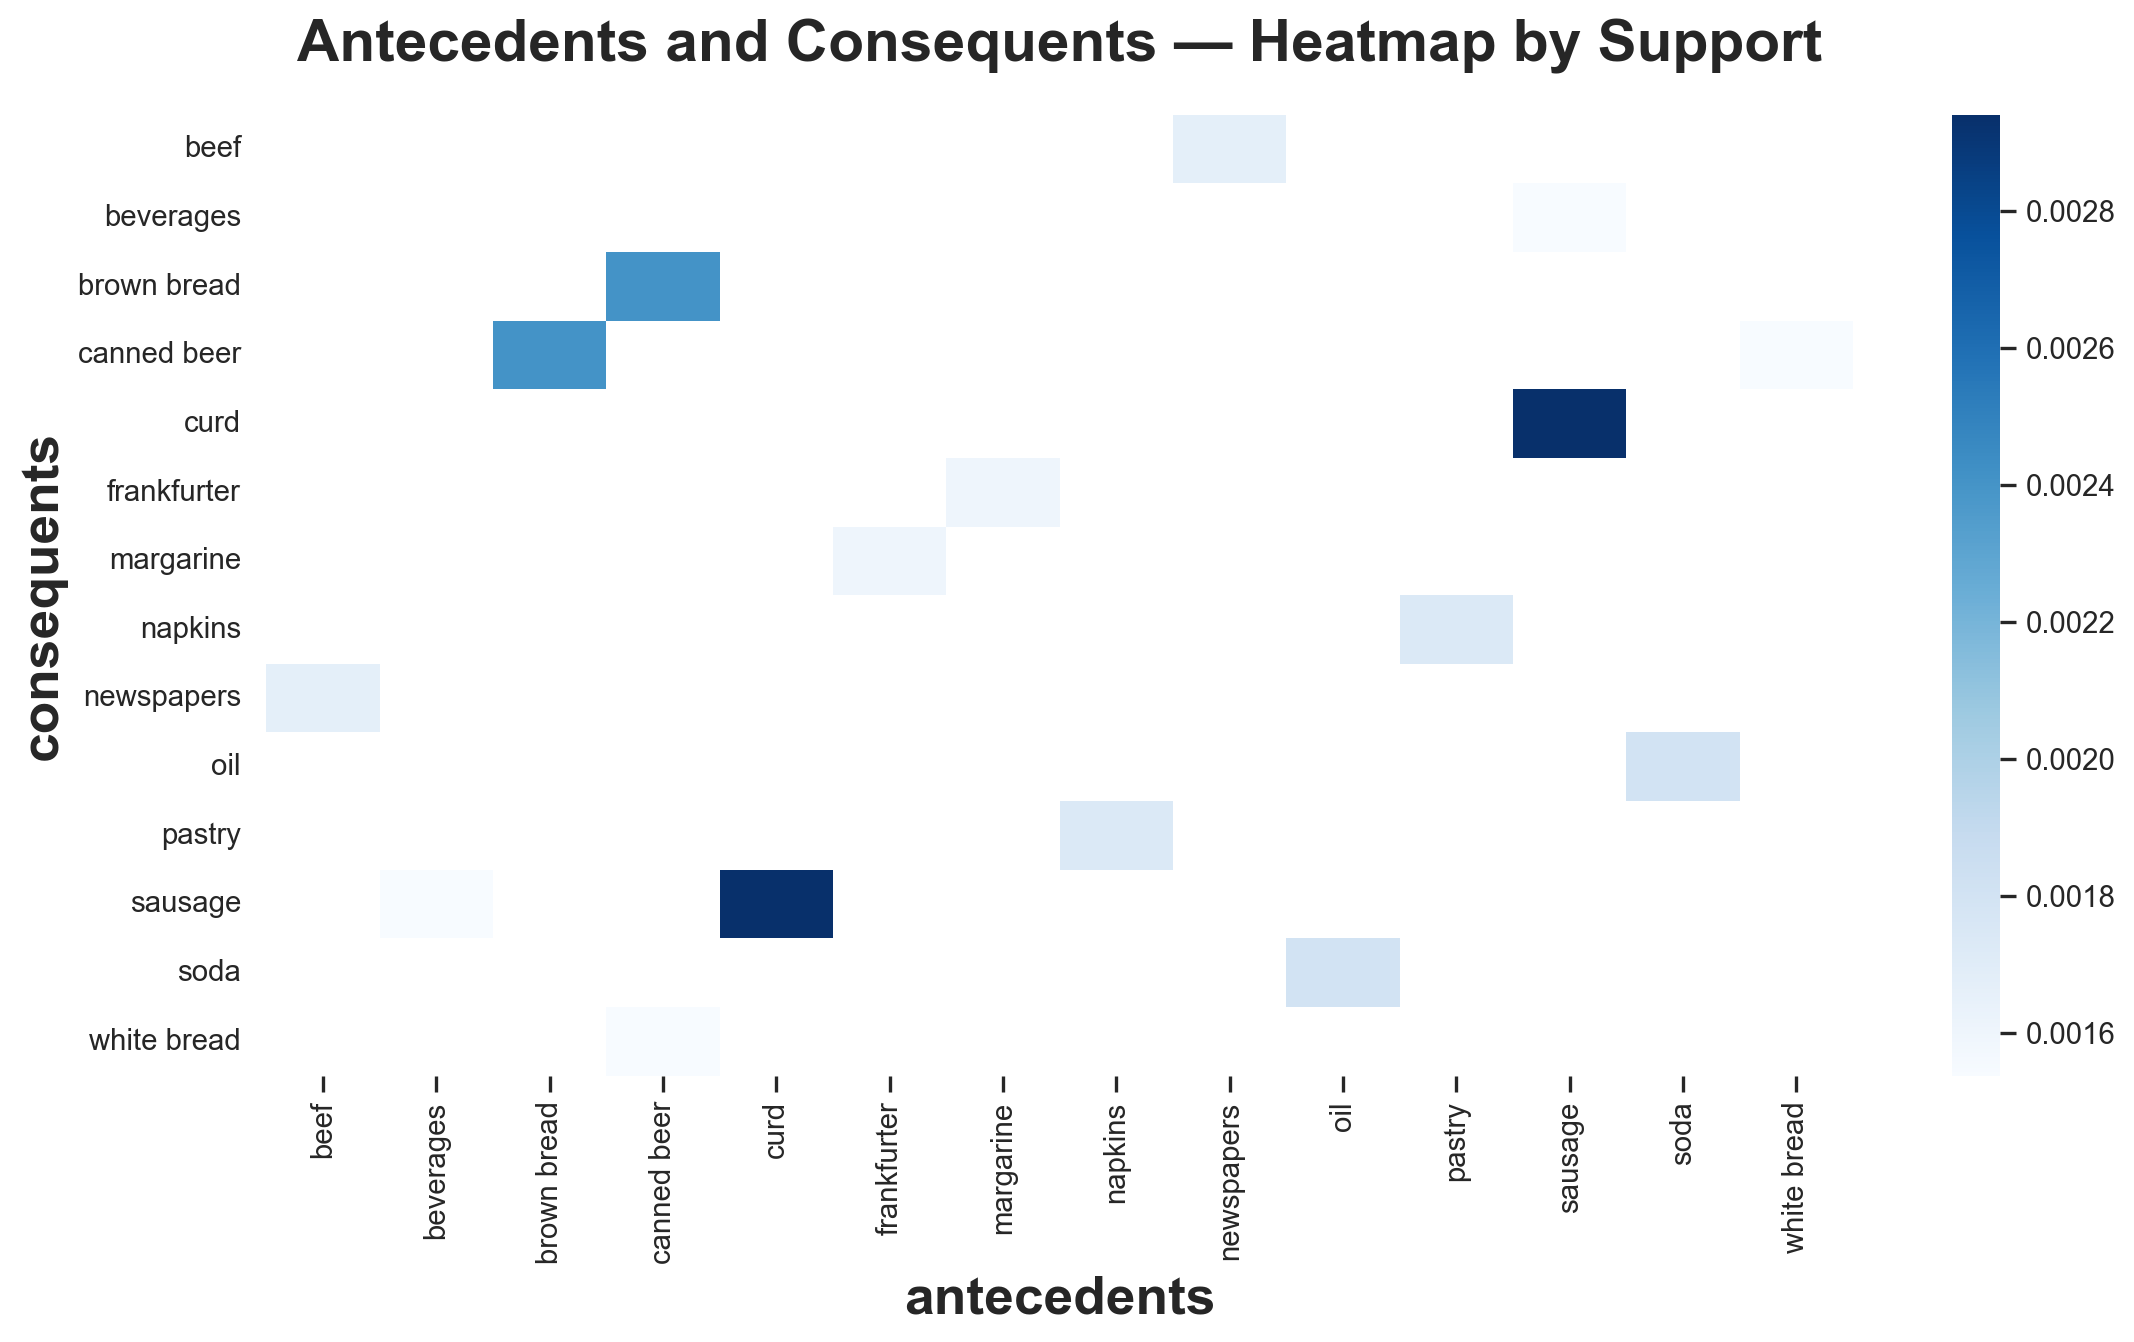

In [27]:
# Transform data to matrix format and generate heatmap
pivot = rules.pivot(index='consequents', columns='antecedents', values='support')
sns.heatmap(pivot, cmap="Blues")

# Title
plt.title('Antecedents and Consequents — Heatmap by Support')

# Format and display plot
plt.yticks(rotation=0)
plt.show()

### `Exploring Lift with Heatmaps`
We turn our attention to the lift metric to identify associations between our products. Lift, with its ability to reveal the strength of co-occurrences, leads us to use the heatmap again, but this time focused on lift.

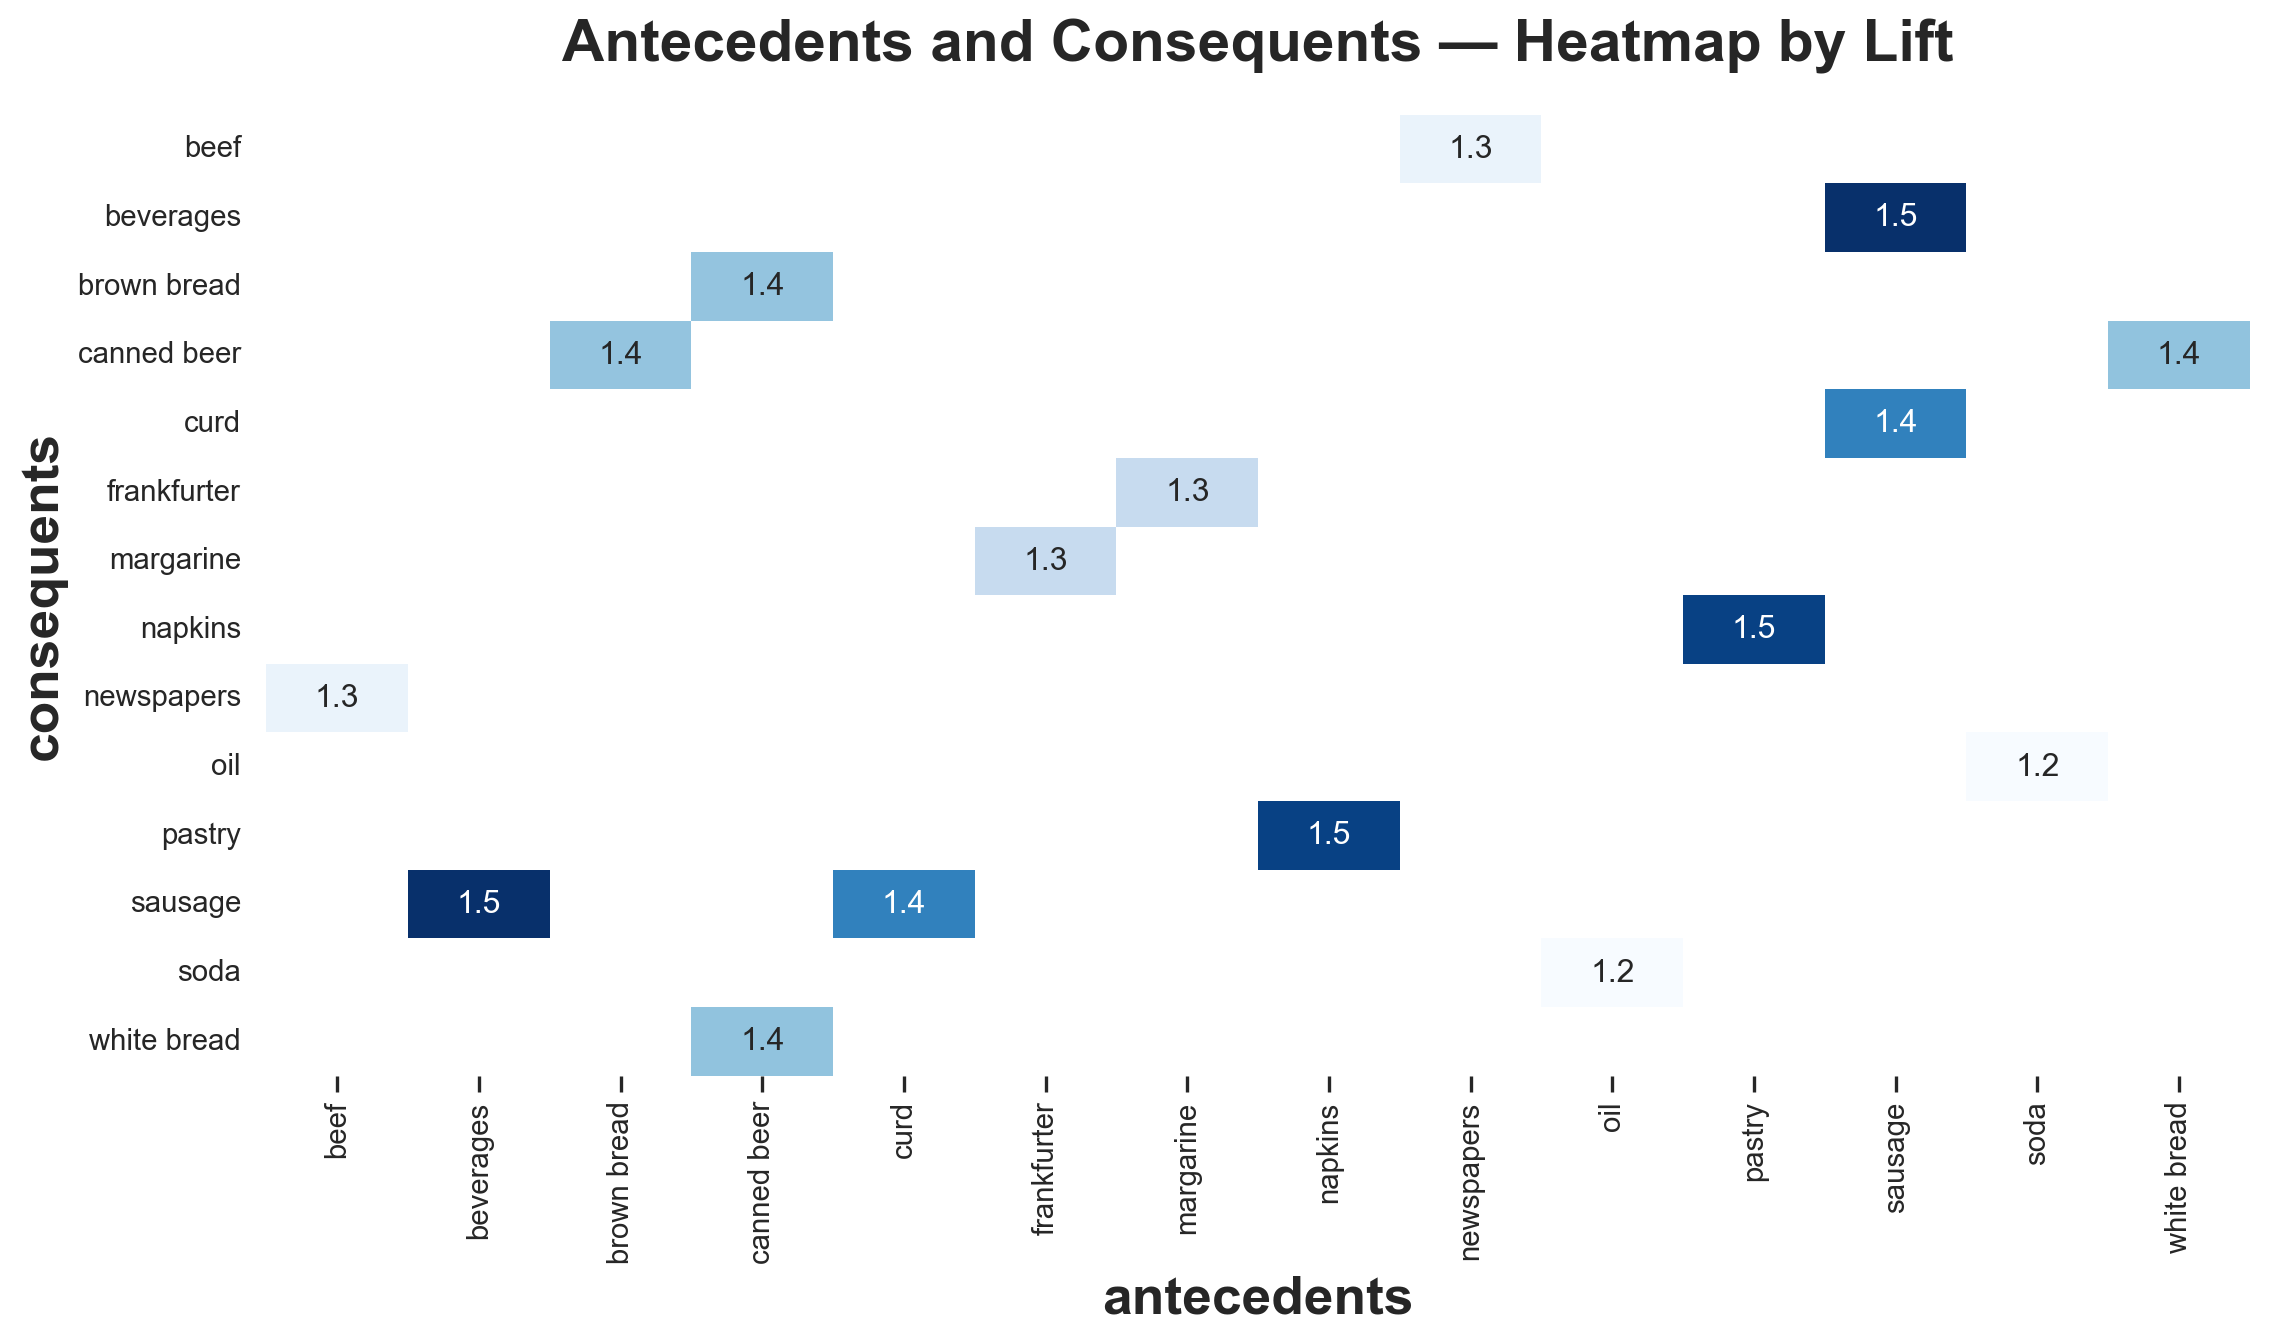

In [28]:
# Transform the DataFrame of rules into a matrix using the lift metric
pivot = rules.pivot(index = 'consequents', 
                   columns = 'antecedents', values= 'lift')

# Generate a heatmap with annotations on and the colorbar off
sns.heatmap(pivot, annot = True, cbar=False, cmap="Blues")

# Title
plt.title('Antecedents and Consequents — Heatmap by Lift')

# Axis
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.show()

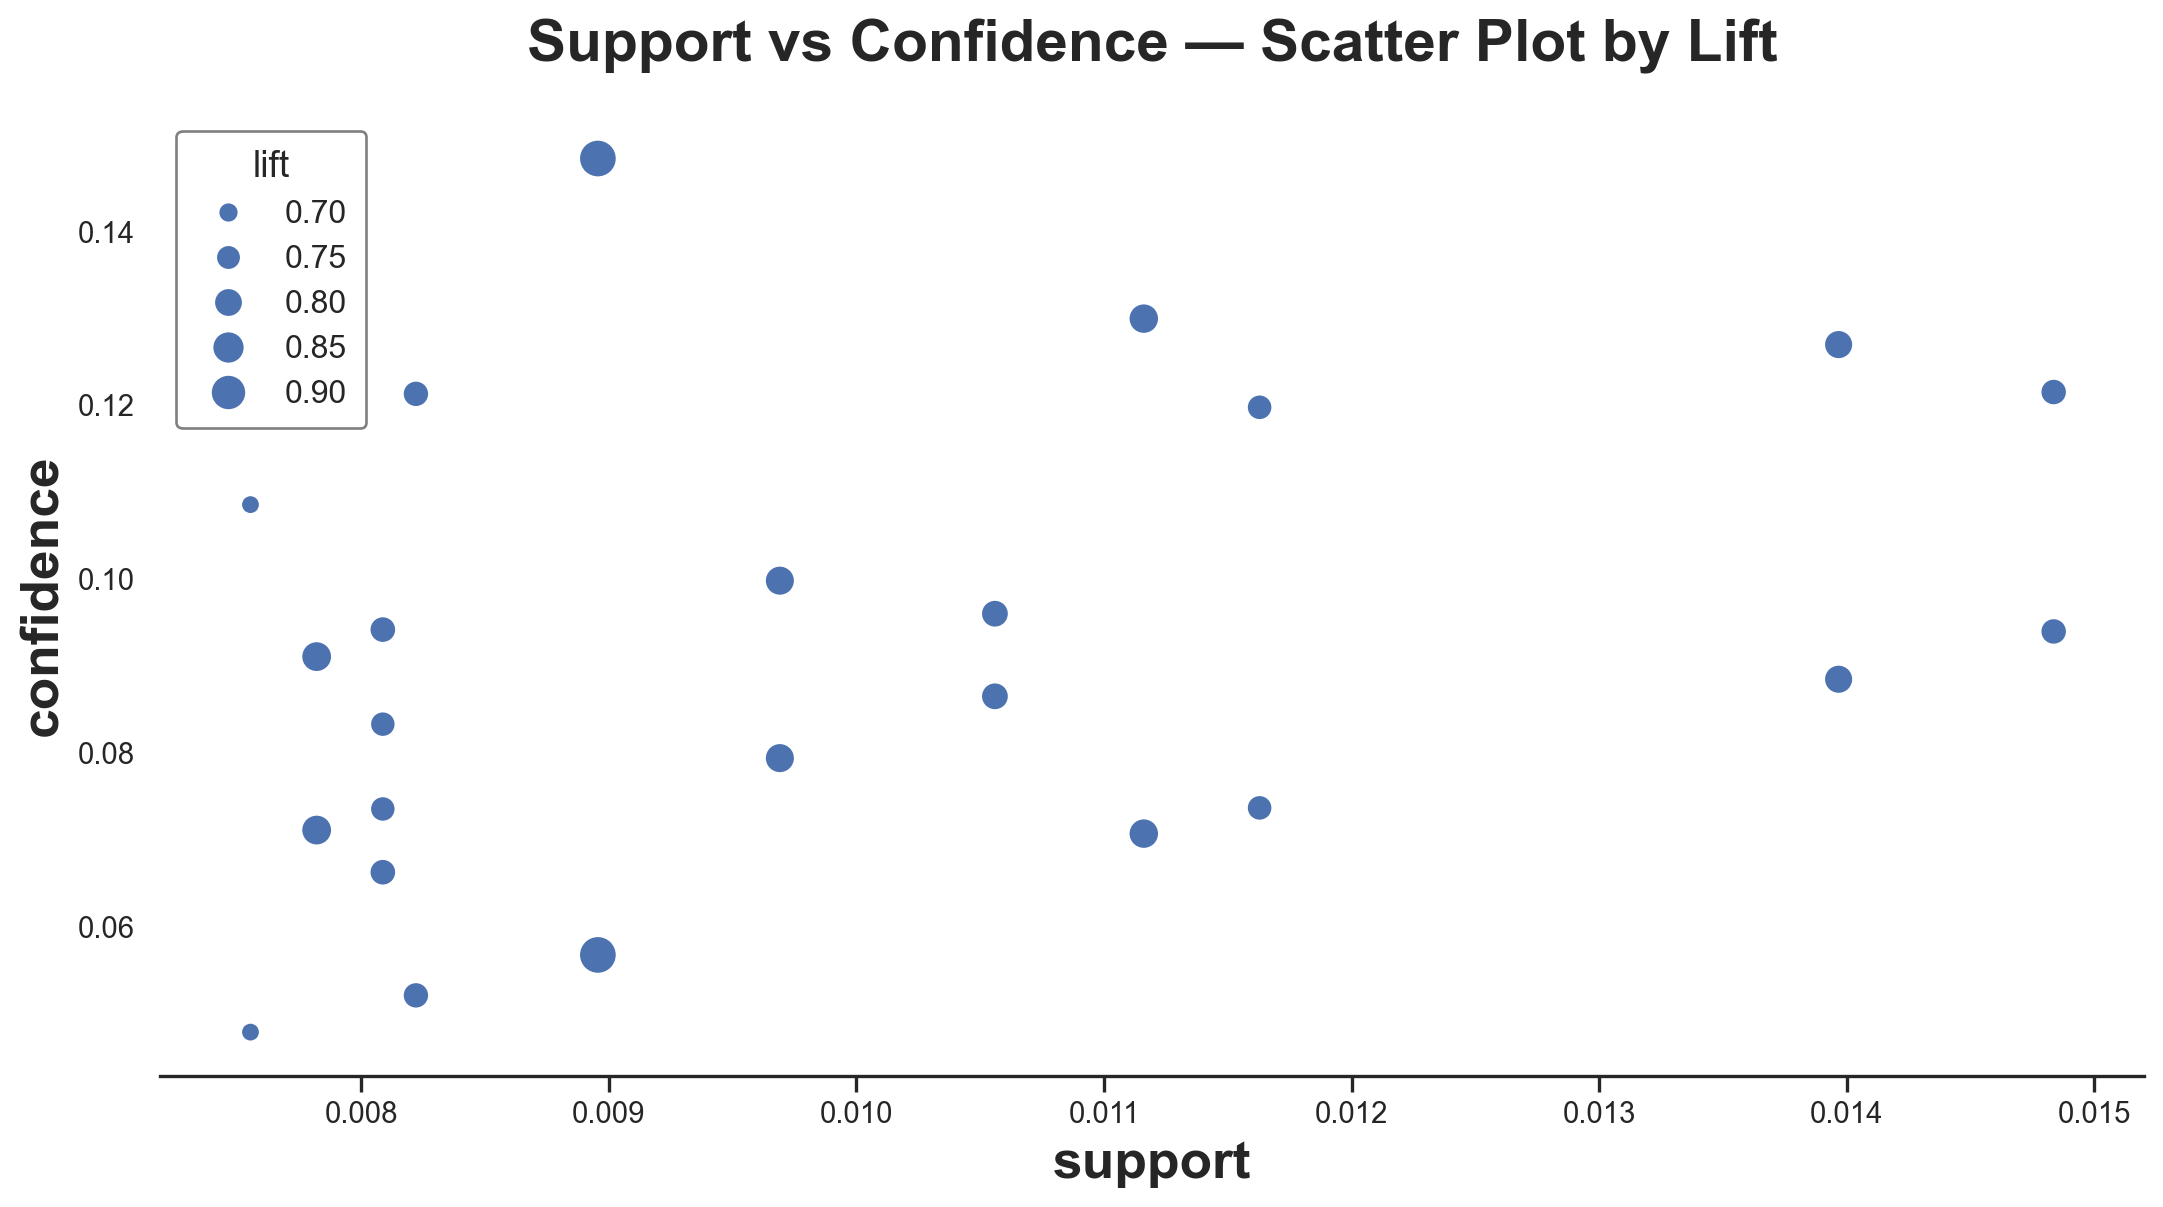

In [29]:
# Apply the Apriori algorithm with a support value of 0.0075
frequent_itemsets = apriori(onehot, min_support = 0.0075, 
                            use_colnames = True, max_len = 2)

# Generate association rules without performing additional pruning
rules = association_rules(frequent_itemsets, metric = 'support', 
                        min_threshold = 0.0)

# Generate scatterplot using support and confidence
sns.scatterplot(x = "support", y = "confidence", 
                size = "lift",
                hue_norm=None, 
                data = rules)

# Title
plt.title('Support vs Confidence — Scatter Plot by Lift')

plt.show()

`The region with the highest lift values concentrates the potentially most relevant associations from an analytical standpoint, as it represents combinations whose co-occurrence exceeds what is expected under independence.`

#### `Parallel Coordinates`

This type of chart allows simultaneously comparing multiple metrics of the rules.

It is useful for identifying rules that balance frequency, reliability, and associative strength.

In [30]:
# Function to convert rules to coordinates.
def rules_to_coordinates(rules):
    rules['antecedent'] = rules['antecedents'].apply(lambda antecedent: list(antecedent)[0])
    rules['consequent'] = rules['consequents'].apply(lambda consequent: list(consequent)[0])
    rules['rule'] = rules.index
    return rules[['antecedent','consequent','rule']]

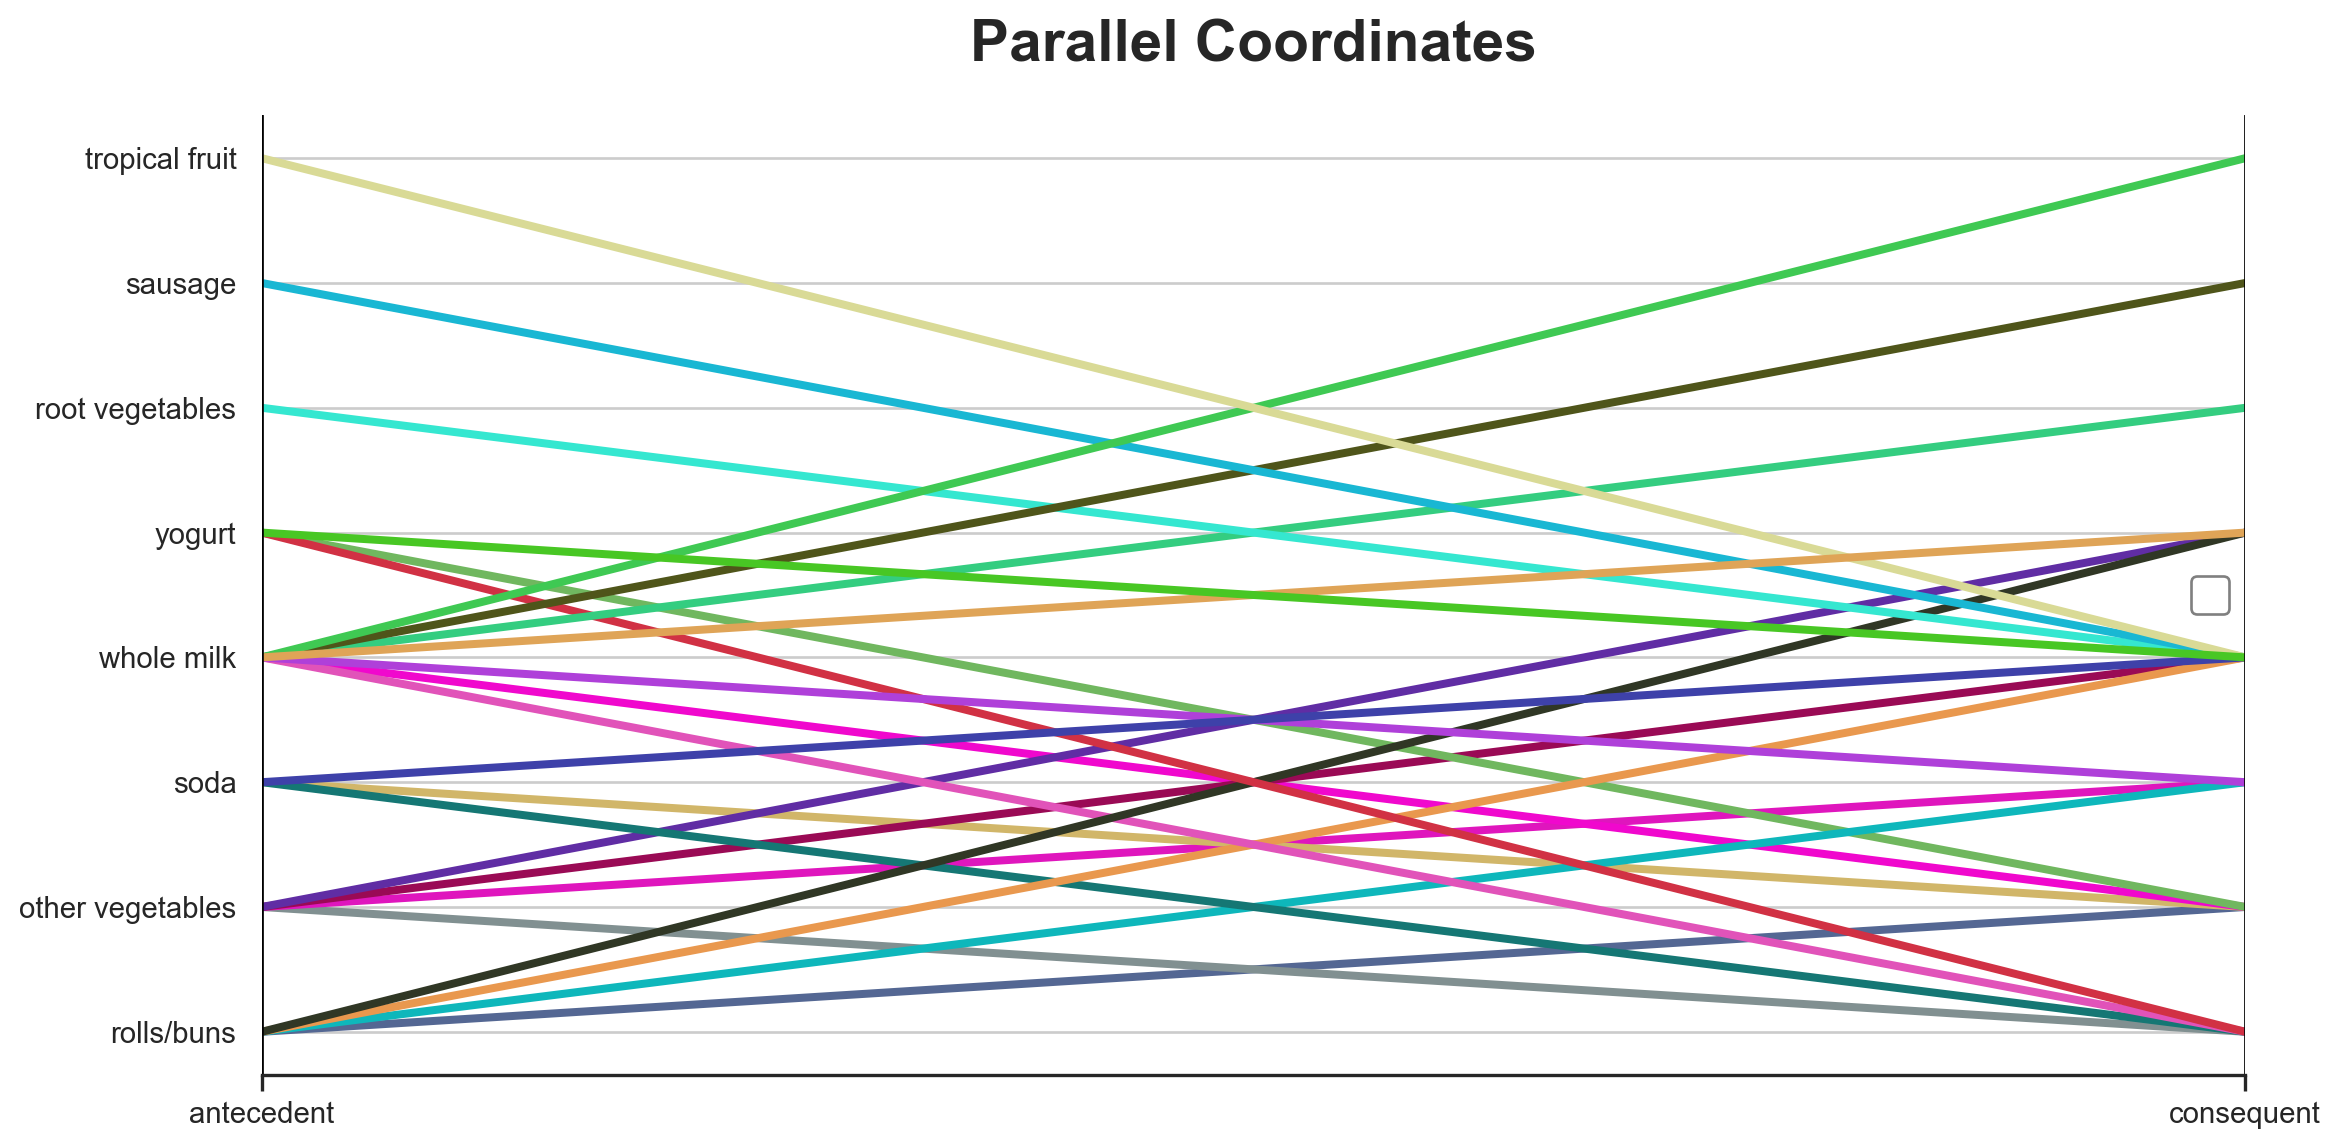

In [31]:
from pandas.plotting import parallel_coordinates

# Apply the Apriori algorithm with a support value of 0.0075
frequent_itemsets = apriori(onehot, min_support = 0.0075, 
                            use_colnames = True, max_len = 2)

# Generate association rules without performing additional pruning
rules = association_rules(frequent_itemsets, metric = 'support', 
                        min_threshold = 0.0)

# Convert rules into coordinates suitable for use in a parallel coordinates plot
coords = rules_to_coordinates(rules)

# Generate parallel coordinates plot
parallel_coordinates(coords, 'rule')
plt.title('Parallel Coordinates')
plt.legend([])
plt.show()

### `Conclusion`

The analysis empirically confirms that **purchase frequency and association strength are distinct dimensions** and should not be treated as equivalent. The two most popular items in the dataset — *whole milk* and *other vegetables* — exhibit a lift of 0.77, conviction of 0.97, and Zhang of −0.26: three metrics converging on the same conclusion that the co-occurrence of these products is lower than expected by chance. Based solely on support, this pair would appear to be an obvious cross-sell candidate; filtered by lift, it is correctly discarded.

The highest-quality rules identified by Apriori — filtered by lift > 1 and Zhang > 0.2 — point to statistically genuine associations with potential for direct application:

| Rule | Lift | Suggested operational application |
|---|---|---|
| **sausage → beverages** | 1.54 | Adjacent shelf placement; barbecue combo |
| **napkins → pastry** | 1.52 | Point-of-sale bundle; contextual suggestion in e-commerce |
| **curd → sausage** | 1.45 | Cross-recommendation at online checkout |
| **brown bread → canned beer** | 1.36 | Weekend promotion; aisle adjacency |

None of these rules involve the most popular products in the catalog — which reinforces the central point: **cross-sell algorithms based solely on popularity rankings miss the most valuable associations**. The combination of Apriori with filters by lift and Zhang's metric offers an objective and replicable framework for prioritizing which product pairs deserve business action.

### `References`

AGRAWAL, R.; IMIELIŃSKI, T.; SWAMI, A. Mining Association Rules between Sets of Items in Large Databases. In: *Proceedings of the 1993 ACM SIGMOD International Conference on Management of Data*. Washington DC, May 25–28, 1993. SIGMOD Record, v. 22, n. 2, p. 207–216, 1993.

AGRAWAL, R.; SRIKANT, R. Fast Algorithms for Mining Association Rules in Large Databases. In: *Proceedings of the 20th International Conference on Very Large Data Bases (VLDB)*. Santiago de Chile, September 12–15, 1994. p. 487–499.

BRIN, S.; MOTWANI, R.; ULLMAN, J. D.; TSUR, S. Dynamic Itemset Counting and Implication Rules for Market Basket Data. In: *Proceedings of the 1997 ACM SIGMOD International Conference on Management of Data*. Tucson, May 13–15, 1997. p. 265–276.

ZHANG, T. Association Rules. In: *Knowledge Discovery and Data Mining: Current Issues and New Applications (PAKDD 2000)*. Lecture Notes in Computer Science, v. 1805. Berlin: Springer, 2000. p. 245–256.